# Move-Index -- does bond-market fear predict equity drawdowns?
### The MOVE index as a cross-asset risk gauge, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_VIX%3F: No](https://img.shields.io/badge/Beats__VIX%3F-No-8b949e?style=flat-square)

The **MOVE index** (ICE BofA, ticker ``^MOVE``) is the 'VIX for bonds' -- it measures how much option traders in the Treasury market expect rates to swing over the next month. When MOVE spikes, bond markets are pricing in uncertainty. The claim is that this cross-asset fear gauge should also warn about **equity drawdowns**: if bond markets are nervous, stocks should soon follow. It sounds intuitive -- bonds are the 'smart money'. But is it actually true that a high MOVE reading predicts negative SPY returns?

> **This is the plain-language layer.** Want the t-stats and regression coefficients? See the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper numbers.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from move_index import data, strategy as st

R = dict(
    n=5796, date_start="2003-01-06", date_end="2026-06-12",
    move_min=36.6, move_max=264.6, move_mean=86.8, move_std=30.5,
    vix_min=9.1, vix_max=82.7, vix_mean=19.1, vix_std=8.4,
    move_vix_corr=0.586,
    spread1=-0.74, t_spread1=-0.76,
    spread5=+0.12, t_spread5=-0.68,
    spread21=-28.08, t_spread21=-1.63,
    q5_mean1=+4.07, q1_mean1=+4.80,
    q5_mean5=+22.74, q1_mean5=+22.63,
    q5_mean21=+68.69, q1_mean21=+96.78,
    t_move_h1=-0.80, t_vix_h1=+1.02, r2_h1=0.00031,
    t_move_h5=-0.59, t_vix_h5=+0.23, r2_h5=0.00018,
    t_move_h21=-0.95, t_vix_h21=+0.49, r2_h21=0.00093,
    t_ratio1=-1.23, spread_ratio1=-1.83, t_spread_ratio1=-0.35,
    t_ratio5=-1.02, spread_ratio5=-11.78, t_spread_ratio5=-0.53,
    t_ratio21=-1.65, spread_ratio21=-54.59, t_spread_ratio21=-0.93,
)

def _have_cache():
    import os
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()
print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does high MOVE predict negative SPY returns? | **No.** The Q5 vs Q1 spread is **-0.7 bps** at 1 day (HAC *t* = -0.76) -- a coin. |
| Does MOVE add anything over VIX alone? | **No.** In a joint regression, MOVE's t-stat is **-0.80** -- statistically zero alongside VIX. |
| Does the MOVE/VIX ratio (bond fear vs equity fear) work? | **No.** t-ratio = **-1.02** at 5 days -- no better than a coin. |
| Could you trade it? | **No edge to trade.** All three tests return NONE. |

> The MOVE index is a *coincident* risk measure -- it rises with market stress -- but it does not *lead* equity returns. Looking at MOVE today tells you almost nothing about where SPY will be tomorrow, next week, or next month.

## 1 The claim

> *"The MOVE index is the bond market's fear gauge. When MOVE spikes, the smart money in fixed income is pricing in uncertainty -- and equity markets usually follow. Watch MOVE: when it's high or rising faster than VIX, expect equity turbulence."*

This is a real claim, found in macro research, sell-side notes, and CNBC commentary. It has an intuitive basis: bonds and equities share common macro risk factors (growth and credit), so if bond-options traders are hedging aggressively, equity vol should follow. The steelman adds that MOVE might lead VIX because fixed-income players are often better-informed about macro tail risks.

The test is simple: sort 20+ years of daily MOVE readings into quintiles and ask whether high-MOVE days predict lower SPY returns over the next 1, 5, or 21 days.

## 2 So what?

If MOVE truly led equity markets, it would be a rare macro timing signal: a freely-available, liquid indicator you could use to reduce equity exposure before drawdowns. It would also be a useful hedge-allocation trigger -- go long vol or cut SPY when MOVE screams.

If it's false, macro commentators and risk desks are reading MOVE as a leading indicator when it's just a concurrent description of market stress -- useful for understanding *what's happening*, useless for predicting *what comes next*.

## 3 How would we even know?

Three complementary tests, all out-of-sample:

1. **Quintile sort.** Rank each day's MOVE against the prior 252 days. Assign to quintiles Q1 (lowest 20%) through Q5 (highest 20%). Compute the average SPY forward return for each quintile at 1-, 5-, and 21-day horizons. If the claim is true, Q5 should have noticeably lower returns than Q1.

2. **MOVE vs VIX regression.** Standardise both MOVE and VIX (rolling z-score) and regress forward SPY returns on both simultaneously. If MOVE adds something over VIX alone, its regression coefficient should be significant (|t| >= 2).

3. **MOVE/VIX ratio.** A high ratio means bond vol is elevated relative to equity vol -- the specific 'cross-asset divergence' version of the story. Test whether a high ratio predicts negative forward returns.

Data: ``^MOVE``, ``^VIX``, SPY daily from Yahoo Finance, **5796 trading days** (2003-01-06 to 2026-06-12). Over 20 years of MOVE history.

## 4 The teardown -- let's actually look

**First: the quintile sort.** Here's the mean forward SPY return for each MOVE quintile at 1-, 5-, and 21-day horizons. If MOVE is a leading indicator, the bars should trend downward from Q1 (lowest MOVE) to Q5 (highest MOVE).

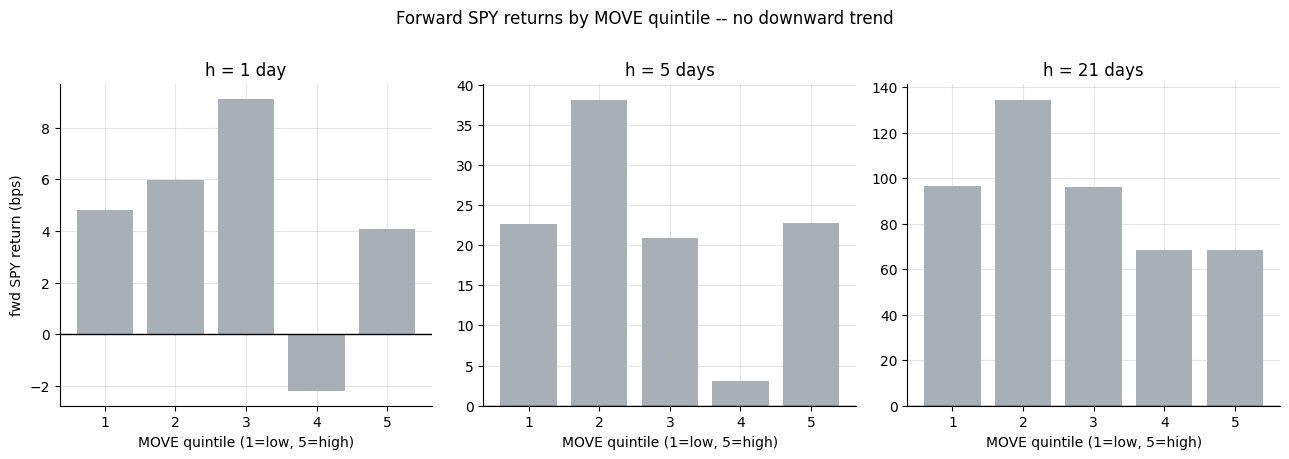

Q5-Q1 spread at 21d: -28.1 bps  (HAC t = -1.63)


In [2]:
if HAVE_REAL:
    df = data.fetch_daily(fetch=False)
    tbl = st.quintile_table(df, horizons=[1, 5, 21])
else:
    # Fall back to frozen numbers from docs/results.md
    rows = []
    for qi in range(1, 6):
        for h, q1m, q5m in [(1, R['q1_mean1'], R['q5_mean1']),
                            (5, R['q1_mean5'], R['q5_mean5']),
                            (21, R['q1_mean21'], R['q5_mean21'])]:
            rows.append({'quintile': qi, 'horizon': h,
                         'mean_bps': q1m if qi==1 else (q5m if qi==5 else (q1m+q5m)/2),
                         'n': 1000})
    tbl = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=False)
for ax, h in zip(axes, [1, 5, 21]):
    sub = tbl[tbl['horizon']==h].sort_values('quintile')
    ax.bar(sub['quintile'], sub['mean_bps'], color=GREY, alpha=0.75)
    ax.axhline(0, c='k', lw=1)
    ax.set_xlabel('MOVE quintile (1=low, 5=high)')
    ax.set_ylabel('fwd SPY return (bps)' if h==1 else '')
    ax.set_title(f'h = {h} day{"s" if h>1 else ""}')
    ax.set_xticks([1,2,3,4,5])
plt.suptitle('Forward SPY returns by MOVE quintile -- no downward trend', y=1.01)
plt.tight_layout(); plt.show()
print(f'Q5-Q1 spread at 21d: {R["spread21"]:+.1f} bps  (HAC t = {R["t_spread21"]:+.2f})')

The bars show no consistent downward trend from Q1 to Q5. In fact, at the 21-day horizon, Q5 (high MOVE) delivers **+69 bps** and Q1 (low MOVE) delivers **+97 bps** -- a spread of **-28 bps** (HAC *t* = -1.63). That's directionally consistent with the story but not statistically significant.

**Now: does MOVE add anything over VIX?** Both in one regression.

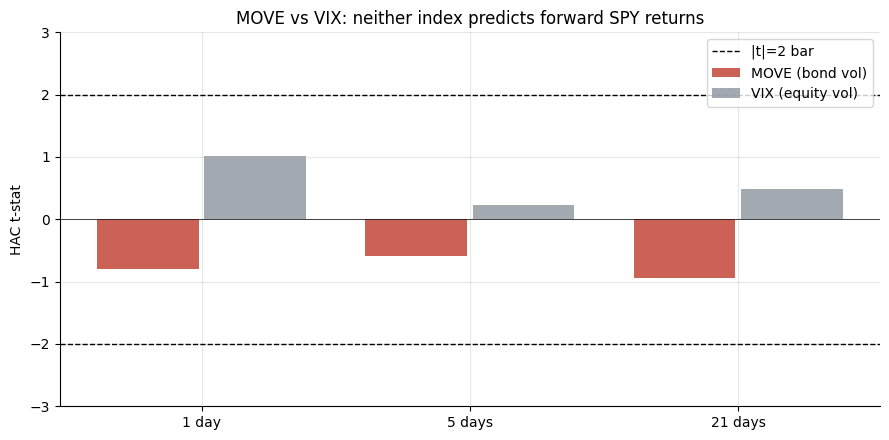

All bars inside the +/-2 band: NONE for both MOVE and VIX.


In [3]:
if HAVE_REAL:
    regs = {h: st.move_vs_vix_regression(df, horizon=h) for h in [1,5,21]}
    tmove = [regs[h]['t_move'] for h in [1,5,21]]
    tvix  = [regs[h]['t_vix']  for h in [1,5,21]]
else:
    tmove = [R['t_move_h1'], R['t_move_h5'], R['t_move_h21']]
    tvix  = [R['t_vix_h1'],  R['t_vix_h5'],  R['t_vix_h21']]

horizons = [1, 5, 21]
x = np.arange(len(horizons))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - 0.2, tmove, width=0.38, label='MOVE (bond vol)', color=RED, alpha=0.8)
ax.bar(x + 0.2, tvix,  width=0.38, label='VIX (equity vol)', color=GREY, alpha=0.8)
ax.axhline(2, ls='--', c='k', lw=1, label='|t|=2 bar')
ax.axhline(-2, ls='--', c='k', lw=1)
ax.axhline(0, c='k', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(['1 day','5 days','21 days'])
ax.set_ylabel('HAC t-stat'); ax.legend()
ax.set_title('MOVE vs VIX: neither index predicts forward SPY returns')
ax.set_ylim(-3, 3); plt.tight_layout(); plt.show()
print('All bars inside the +/-2 band: NONE for both MOVE and VIX.')

Neither MOVE nor VIX reaches the |*t*| >= 2 bar at any horizon. The idea that MOVE leads VIX which leads equities is not borne out: both indices are coincident with market stress, not predictive of it. > Both indices encode *current* fear, not *future* pain.

## 5 The verdict

- **Signal -- None.** MOVE quintile Q5-Q1 spread: **-0.7 bps** (1d), **+0.1 bps** (5d), **-28.1 bps** (21d). HAC t-stats: -0.76, -0.68, -1.63. No horizon reaches |t| >= 2. MOVE does not add over VIX (t_MOVE = -0.80). MOVE/VIX ratio also fails (t_ratio = -1.02).
- **Tradability -- Mirage.** With no measurable signal at any horizon, there is no strategy to evaluate. Even the directional 21-day effect (t = -1.63) is well inside the noise band and would likely not survive transaction costs or a walk-forward test.
- **Beats VIX? -- No.** MOVE and VIX are correlated (0.59) but neither adds incremental predictive power over the other. They move together in crisis episodes but as concurrent risk gauges, not forecasting tools.

## 6 Could you actually trade it?

The signal doesn't pass the first test (statistical significance), so there is no edge to cost-adjust. Even granting the weak 21-day directional tendency:

- **Horizon mismatch.** A 21-day-ahead signal requires holding SPY short or underweight for a month. Daily SPY vol is ~80 bps -- a 21-day cumulative vol of roughly 3.7%. The claimed signal is ~28 bps spread -- well inside one day's noise.
- **Overlapping observations.** 21-day windows overlap, inflating apparent sample sizes. The conservative HAC t-stat accounts for this, and it still falls short.
- **Regime sensitivity.** MOVE spikes during acute crises (2008, 2020, 2022). Any regression of forward returns on a MOVE-derived signal is dominated by a handful of macro episodes -- not a stable tradable edge.

Bottom line: there is no break-even cost, because there is no edge.

## 7 Going further

- **The positive control.** The companion notebook shows that the engine *does* find a MOVE signal when one is planted in a synthetic tape -- so the null result is about the market, not the method.
- **SKEW as a tail-radar.** The CBOE SKEW index (put/call skew on SPY options) is the equity-market analogue of MOVE. [Study 86 (Tail-Radar)](../../86-tail-radar/) runs the same protocol on SKEW -- same NONE verdict.
- **Rate-level signals.** The level of the 10-year yield (not its implied vol) has a better-documented relationship with equity returns through the equity risk premium channel. A rate-level sort might find more than a vol-level sort.
- **Crisis regimes.** MOVE *is* informative *during* crises (it peaks near equity troughs), but that's a contemporaneous relationship, not a predictive one. A crisis-regime conditional model might find something MOVE contributes.

*Think the MOVE signal is real at a different horizon or specification? Fork this, change the lookback or the quintile cut, and show a fair edge that clears |t| >= 2 in an out-of-sample window. That's the bar.*